# Imágenes Elegidas

Aliasing

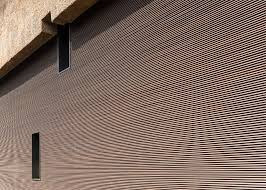
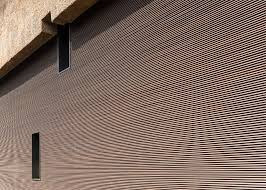

Moiré

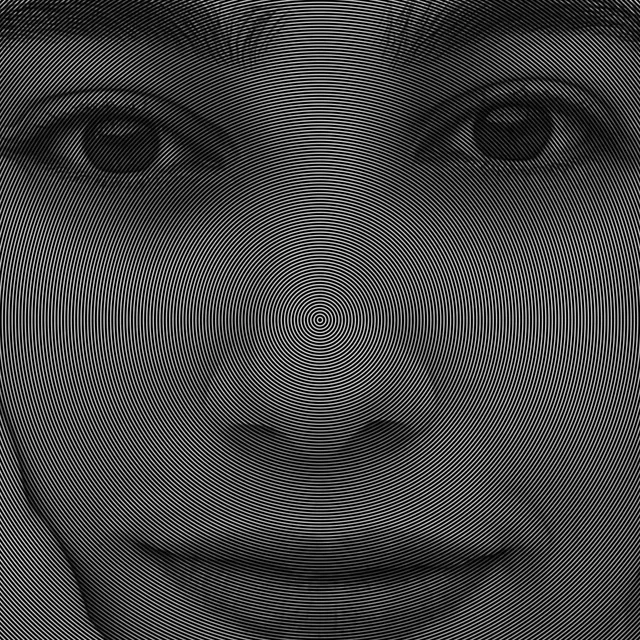
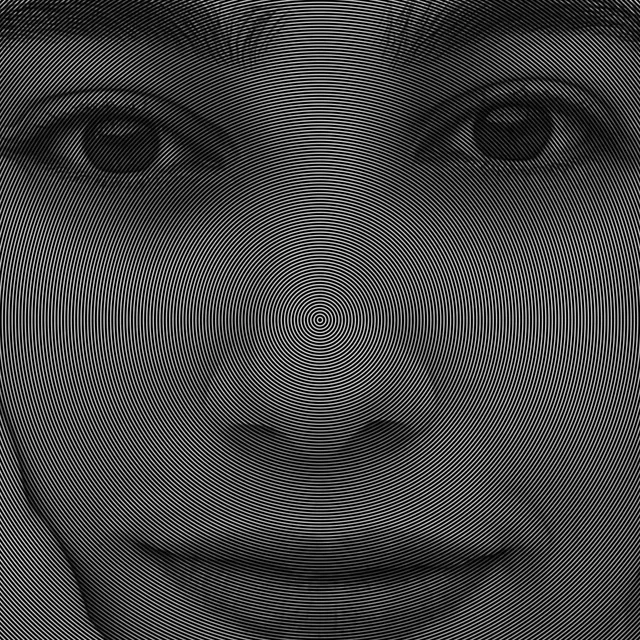

Para contrastar los efectos de moiré y aliasing, comparé la imagen original con la imagen arreglada y la imagen final con más nitidez.
En el caso del moiré usé filtros de convolución horizontales y verticales para quitar esos patrones de rayas repetitivas. Después usé un filtro bilateral para suavizar la imagen sin borrar las orillas de los objetos. Luego, pasé la imagen al espacio de color LAB y usé CLAHE para mejorar el brillo y el contraste, y al final hice un proceso de sharpening con desenfoque gaussiano para que la imagen se viera más clarita de nuevo.
Para el aliasing primero apliqué un suavizado gaussiano y cambié el tamaño de la imagen (la hice chica y luego grande otra vez) para quitarle lo serruchado a los bordes. Después usé un filtro bilateral para cuidar los contornos y mejoré la nitidez en la parte del brillo. Por último, di un retoque de nitidez general para que la imagen se viera bien definida.
Al comparar los resultados me di cuenta de cómo cada paso ayudó a quitar los errores de la imagen logrando que se vea limpia pero sin perder los detalles.

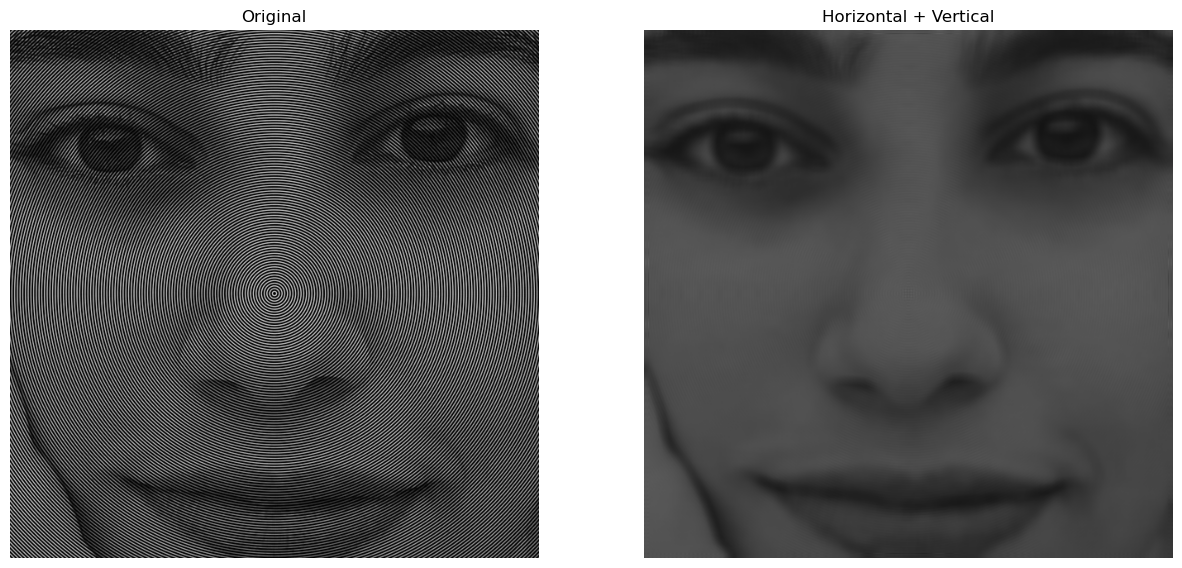

In [42]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def convolucion_media_h(img, tkernel):
    kernel = np.ones((1, tkernel), np.float32) / tkernel
    return cv2.filter2D(img, -1, kernel)

def convolucion_media_v(img, tkernel):
    kernel = np.ones((tkernel, 1), np.float32) / tkernel
    return cv2.filter2D(img, -1, kernel)

img = cv2.imread('moire.jpg')

img_h = convolucion_media_h(img, 13)
img_hv = convolucion_media_v(img_h, 13)

plt.figure(figsize=(15, 8))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("Horizontal + Vertical")
plt.imshow(cv2.cvtColor(img_hv, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()

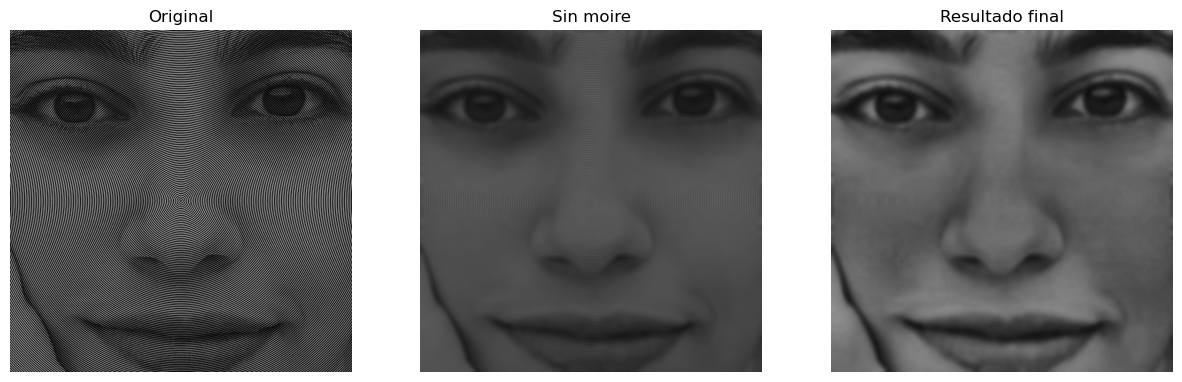

In [36]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def convolucion_media_h(img, k):
    kernel = np.ones((1, k), np.float32) / k
    return cv2.filter2D(img, -1, kernel)

def convolucion_media_v(img, k):
    kernel = np.ones((k, 1), np.float32) / k
    return cv2.filter2D(img, -1, kernel)

img = cv2.imread('moire.jpg')

img_h = convolucion_media_h(img, 11)
img_hv = convolucion_media_v(img_h, 11)

img_bilateral = cv2.bilateralFilter(img_hv, 9, 75, 75)

lab = cv2.cvtColor(img_bilateral, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
l_clahe = clahe.apply(l)

blur = cv2.GaussianBlur(l_clahe, (0,0), 1)
l_sharp = cv2.addWeighted(l_clahe, 1.5, blur, -0.5, 0)

lab_final = cv2.merge((l_sharp, a, b))
img_final = cv2.cvtColor(lab_final, cv2.COLOR_LAB2BGR)

plt.figure(figsize=(15,8))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Sin moire")
plt.imshow(cv2.cvtColor(img_hv, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Resultado final")
plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()

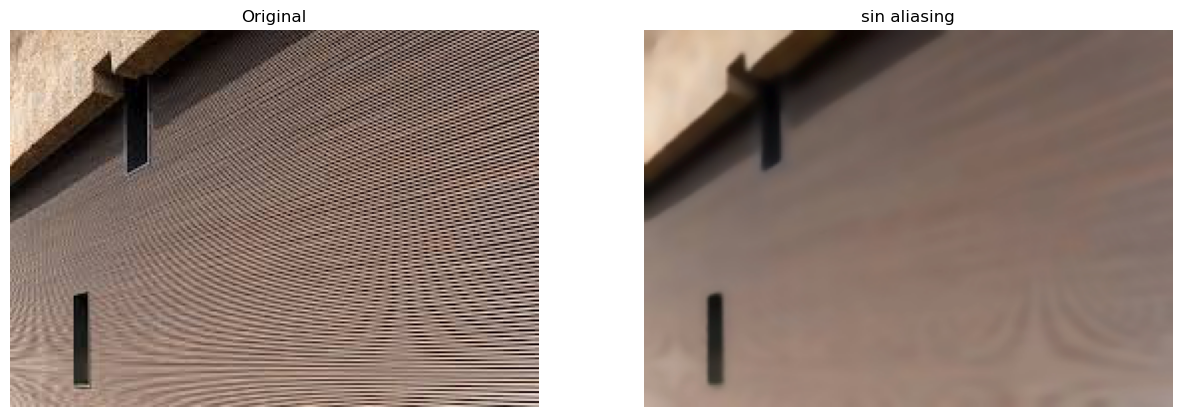

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('aliasing.jpeg')

img_blur = cv2.GaussianBlur(img, (5,5), 0)

small = cv2.resize(img_blur, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

up = cv2.resize(small, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_CUBIC)

img_bilateral = cv2.bilateralFilter(up, 9, 75, 75)

lab = cv2.cvtColor(img_bilateral, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

blur = cv2.GaussianBlur(l, (0,0), 1)
l_sharp = cv2.addWeighted(l, 1.2, blur, -0.2, 0)

lab_final = cv2.merge((l_sharp, a, b))
img_final = cv2.cvtColor(lab_final, cv2.COLOR_LAB2BGR)

plt.figure(figsize=(15,8))

plt.subplot(1,2,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,2,2)
plt.title("sin aliasing")
plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()

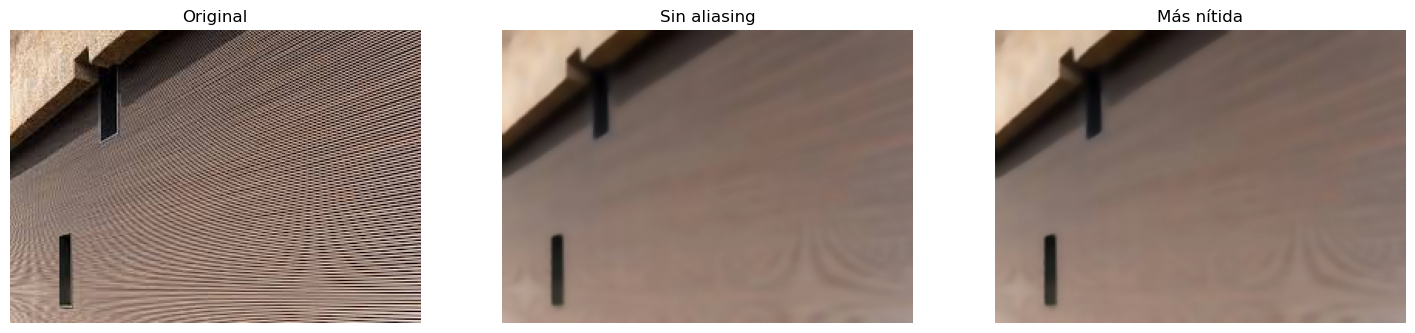

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('aliasing.jpeg')

img_blur = cv2.GaussianBlur(img, (5,5), 0)

small = cv2.resize(img_blur, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

up = cv2.resize(small, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_CUBIC)

img_bilateral = cv2.bilateralFilter(up, 9, 75, 75)

lab = cv2.cvtColor(img_bilateral, cv2.COLOR_BGR2LAB)
l, a, b = cv2.split(lab)

blur = cv2.GaussianBlur(l, (0,0), 1)
l_sharp = cv2.addWeighted(l, 1.2, blur, -0.2, 0)

lab_final = cv2.merge((l_sharp, a, b))
img_final = cv2.cvtColor(lab_final, cv2.COLOR_LAB2BGR)

blur2 = cv2.GaussianBlur(img_final, (0,0), 1)
img_sharp_final = cv2.addWeighted(img_final, 1.3, blur2, -0.3, 0)

plt.figure(figsize=(18,6))

plt.subplot(1,3,1)
plt.title("Original")
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,3,2)
plt.title("Sin aliasing")
plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.subplot(1,3,3)
plt.title("Más nítida")
plt.imshow(cv2.cvtColor(img_sharp_final, cv2.COLOR_BGR2RGB))
plt.axis('off')

plt.show()